# High-Performance LLM Inference Gateway
- Control plane / data plane separation via gRPC
- KV-aware request routing (cache-aware prefix hashing)
- Continuous batching with dynamic batch sizing
- P99 latency measurement under concurrent load

---
## Architecture
```
Client Requests
      │
      ▼
┌─────────────────────────────────────┐
│         CONTROL PLANE               │
│  ┌──────────┐   ┌─────────────────┐ │
│  │ Admission│   │  KV-Aware       │ │
│  │ Control  │──▶│  Router         │ │
│  └──────────┘   └─────────┬───────┘ │
└───────────────────────────┼─────────┘
           gRPC             │
┌───────────────────────────▼─────────┐
│           DATA PLANE                │
│  ┌──────────────────────────────┐   │
│  │   Continuous Batching Engine │   │
│  │  Worker0  Worker1  Worker2   │   │
│  └──────────────────────────────┘   │
└─────────────────────────────────────┘
```

## 1. Install Dependencies

In [4]:
!pip install grpcio grpcio-tools transformers accelerate torch --quiet
import subprocess, sys, torch
if torch.cuda.is_available():
    try:
        subprocess.run([sys.executable, '-m', 'pip', 'install', 'vllm', '--quiet'], timeout=300)
        print('vLLM installed')
    except Exception as e:
        print(f'vLLM skipped: {e}')
else:
    print('No GPU — using mock inference engine')
print('Core dependencies ready')

vLLM installed
Core dependencies ready


In [5]:
import vllm
print(vllm.__version__)

0.17.0


## 2. Define gRPC Proto & Generate Stubs

In [2]:
import os

PROTO = '''
syntax = "proto3";
package llmgateway;

service ControlPlane {
  rpc RouteRequest (RouteReq)   returns (RouteResp);
  rpc Admit        (AdmitReq)   returns (AdmitResp);
  rpc GetStats     (StatsReq)   returns (StatsResp);
}

message RouteReq  { string request_id = 1; string prompt = 2; int32 max_tokens = 3; }
message RouteResp { string worker_id  = 1; string cache_key = 2; bool cache_hit = 3; }
message AdmitReq  { string request_id = 1; int32 estimated_tokens = 2; }
message AdmitResp { bool admitted = 1; string reason = 2; }
message StatsReq  {}
message StatsResp {
  map<string, float> worker_load = 1;
  int32 queue_depth = 2;
  float cache_hit_rate = 3;
}

service InferenceWorker {
  rpc Infer       (InferReq)       returns (InferResp);
  rpc BatchInfer  (BatchReq)       returns (BatchResp);
  rpc WorkerStats (WorkerStatsReq) returns (WorkerStatsResp);
}

message InferReq  { string request_id = 1; string prompt = 2; int32 max_tokens = 3; string cache_key = 4; }
message InferResp { string request_id = 1; string output = 2; int32 tokens_generated = 3; float latency_ms = 4; bool cache_hit = 5; }
message BatchReq  { repeated InferReq requests = 1; int32 batch_size = 2; }
message BatchResp { repeated InferResp responses = 1; float batch_latency_ms = 2; }
message WorkerStatsReq {}
message WorkerStatsResp { string worker_id = 1; float gpu_util = 2; int32 kv_cache_blocks_used = 3; int32 kv_cache_blocks_free = 4; int32 requests_served = 5; }
'''

os.makedirs('/content/proto', exist_ok=True)
with open('/content/proto/gateway.proto', 'w') as f:
    f.write(PROTO)

!python -m grpc_tools.protoc \
    -I /content/proto \
    --python_out=/content/proto \
    --grpc_python_out=/content/proto \
    /content/proto/gateway.proto

import sys
sys.path.insert(0, '/content/proto')
print('gRPC stubs generated')

gRPC stubs generated


## 3. KV-Cache Manager

In [6]:
import hashlib, time, threading, random
from collections import OrderedDict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import numpy as np

@dataclass
class KVBlock:
    key: str
    prefix: str
    worker_id: str
    created_at: float = field(default_factory=time.time)
    last_accessed: float = field(default_factory=time.time)
    hit_count: int = 0


class KVCacheManager:
    """
    Tracks which prompt prefixes are cached on which workers.
    Uses prefix-length hashing: longer shared prefix => higher affinity.
    """
    def __init__(self, max_blocks: int = 512, block_size: int = 16):
        self.max_blocks = max_blocks
        self.block_size = block_size
        self._cache: Dict[str, KVBlock] = {}
        self._worker_blocks: Dict[str, List[str]] = {}
        self._lock = threading.Lock()
        self.hits = 0
        self.misses = 0

    @staticmethod
    def _prefix_hash(prompt: str, prefix_len: int) -> str:
        prefix = prompt[:prefix_len]
        return hashlib.sha256(prefix.encode()).hexdigest()[:16]

    def best_cache_key(self, prompt: str) -> Tuple[str, int]:
        best_key, best_len = None, 0
        for prefix_len in range(len(prompt), 0, -self.block_size):
            key = self._prefix_hash(prompt, prefix_len)
            if key in self._cache:
                best_key, best_len = key, prefix_len
                break
        if best_key is None:
            best_key = self._prefix_hash(prompt, len(prompt))
        return best_key, best_len

    def lookup(self, cache_key: str) -> Optional[KVBlock]:
        with self._lock:
            block = self._cache.get(cache_key)
            if block:
                block.last_accessed = time.time()
                block.hit_count += 1
                self.hits += 1
                return block
            self.misses += 1
            return None

    def store(self, cache_key: str, prefix: str, worker_id: str):
        with self._lock:
            if len(self._cache) >= self.max_blocks:
                self._evict_lru()
            self._cache[cache_key] = KVBlock(key=cache_key, prefix=prefix, worker_id=worker_id)
            self._worker_blocks.setdefault(worker_id, []).append(cache_key)

    def _evict_lru(self):
        lru_key = min(self._cache, key=lambda k: self._cache[k].last_accessed)
        block = self._cache.pop(lru_key)
        if block.worker_id in self._worker_blocks:
            self._worker_blocks[block.worker_id] = [
                k for k in self._worker_blocks[block.worker_id] if k != lru_key
            ]

    def worker_for_key(self, cache_key: str) -> Optional[str]:
        block = self._cache.get(cache_key)
        return block.worker_id if block else None

    @property
    def hit_rate(self) -> float:
        total = self.hits + self.misses
        return self.hits / total if total > 0 else 0.0

    def stats(self) -> dict:
        return {
            'blocks_used': len(self._cache),
            'blocks_free': self.max_blocks - len(self._cache),
            'hits': self.hits,
            'misses': self.misses,
            'hit_rate': round(self.hit_rate, 3),
        }

print('KVCacheManager defined')

KVCacheManager defined


## 4. Inference Workers (Data Plane)

In [7]:
import torch, queue

GPU_AVAILABLE = torch.cuda.is_available()
try:
    from vllm import LLM, SamplingParams
    VLLM_AVAILABLE = True
except ImportError:
    VLLM_AVAILABLE = False

print(f'GPU: {GPU_AVAILABLE} | vLLM: {VLLM_AVAILABLE}')


@dataclass
class InferRequest:
    request_id: str
    prompt: str
    max_tokens: int
    cache_key: str = ''
    arrival_time: float = field(default_factory=time.time)

@dataclass
class InferResponse:
    request_id: str
    output: str
    tokens_generated: int
    latency_ms: float
    cache_hit: bool
    worker_id: str


class MockInferenceEngine:
    """Simulates token generation with realistic latency (CPU fallback)."""
    def __init__(self, worker_id: str, base_latency_ms: float = 50.0):
        self.worker_id = worker_id
        self.base_latency_ms = base_latency_ms
        self.kv_cache: Dict[str, str] = {}
        self.requests_served = 0

    def generate(self, req: InferRequest) -> InferResponse:
        start = time.time()
        cache_hit = req.cache_key in self.kv_cache
        # Cache hit: ~3x faster
        latency = (self.base_latency_ms * 0.3 + random.gauss(0, 3)
                   if cache_hit
                   else self.base_latency_ms + req.max_tokens * 0.8 + random.gauss(0, 8))
        latency = max(latency, 1.0)
        time.sleep(latency / 1000.0)

        output = f'[{self.worker_id}] Response: "{req.prompt[:40]}..." ({req.max_tokens} tokens)'
        if not cache_hit:
            self.kv_cache[req.cache_key] = output
        self.requests_served += 1
        return InferResponse(
            request_id=req.request_id, output=output,
            tokens_generated=req.max_tokens,
            latency_ms=(time.time() - start) * 1000,
            cache_hit=cache_hit, worker_id=self.worker_id,
        )


class VLLMInferenceEngine:
    """Wraps vLLM for real GPU inference (singleton model)."""
    _model = None

    def __init__(self, worker_id: str, model_name: str = 'facebook/opt-125m'):
        self.worker_id = worker_id
        self.requests_served = 0
        if VLLMInferenceEngine._model is None:
            print(f'  Loading {model_name} into vLLM...')
            VLLMInferenceEngine._model = LLM(model=model_name, dtype='float16',
                                              gpu_memory_utilization=0.85)
            print('  vLLM model loaded')

    def generate(self, req: InferRequest) -> InferResponse:
        start = time.time()
        params = SamplingParams(temperature=0.7, max_tokens=req.max_tokens)
        outputs = VLLMInferenceEngine._model.generate([req.prompt], params)
        text = outputs[0].outputs[0].text
        tokens = len(outputs[0].outputs[0].token_ids)
        self.requests_served += 1
        return InferResponse(
            request_id=req.request_id, output=text, tokens_generated=tokens,
            latency_ms=(time.time() - start) * 1000,
            cache_hit=False, worker_id=self.worker_id,
        )

print('Inference engines defined')

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU: True | vLLM: True
Inference engines defined


## 5. Continuous Batching Engine

In [8]:
class ContinuousBatchingEngine:
    """
    Continuous batching with dynamic batch size controller.
    P99 feedback: shrink batch if tail latency too high, grow if headroom available.
    """
    def __init__(self, engine, min_batch=1, max_batch=8,
                 target_p99_ms=500.0, batch_timeout_ms=20.0):
        self.engine = engine
        self.min_batch = min_batch
        self.max_batch = max_batch
        self.target_p99_ms = target_p99_ms
        self.batch_timeout_ms = batch_timeout_ms
        self._queue: queue.Queue = queue.Queue()
        self._results: Dict[str, InferResponse] = {}
        self._latencies: List[float] = []
        self._current_batch_size = min_batch
        self._lock = threading.Lock()
        self._running = False
        self.total_batches = 0
        self.total_requests = 0
        self.batch_size_history: List[int] = []

    def start(self):
        self._running = True
        t = threading.Thread(target=self._batch_loop, daemon=True)
        t.start()

    def stop(self):
        self._running = False

    def submit(self, req: InferRequest) -> threading.Event:
        event = threading.Event()
        self._queue.put((req, event))
        return event

    def get_result(self, request_id: str) -> Optional[InferResponse]:
        return self._results.get(request_id)

    def _adjust_batch_size(self):
        if len(self._latencies) < 10:
            return
        recent = self._latencies[-20:]
        p99 = np.percentile(recent, 99)
        p50 = np.percentile(recent, 50)
        if p99 > self.target_p99_ms * 1.2:
            self._current_batch_size = max(self.min_batch, self._current_batch_size - 1)
        elif p99 < self.target_p99_ms * 0.7 and p50 < self.target_p99_ms * 0.4:
            self._current_batch_size = min(self.max_batch, self._current_batch_size + 1)

    def _batch_loop(self):
        while self._running:
            batch_items = []
            deadline = time.time() + self.batch_timeout_ms / 1000.0
            while len(batch_items) < self._current_batch_size:
                remaining = deadline - time.time()
                if remaining <= 0:
                    break
                try:
                    item = self._queue.get(timeout=max(remaining, 0.001))
                    batch_items.append(item)
                except queue.Empty:
                    break
            if not batch_items:
                continue
            for req, event in batch_items:
                resp = self.engine.generate(req)
                with self._lock:
                    self._results[req.request_id] = resp
                    self._latencies.append(resp.latency_ms)
                event.set()
            self.total_batches += 1
            self.total_requests += len(batch_items)
            self.batch_size_history.append(len(batch_items))
            self._adjust_batch_size()

    def latency_percentiles(self) -> dict:
        if not self._latencies:
            return {}
        arr = np.array(self._latencies)
        return {
            'p50':  round(float(np.percentile(arr, 50)),  2),
            'p90':  round(float(np.percentile(arr, 90)),  2),
            'p99':  round(float(np.percentile(arr, 99)),  2),
            'mean': round(float(arr.mean()), 2),
            'count': len(arr),
        }

print('ContinuousBatchingEngine defined')

ContinuousBatchingEngine defined


## 6. Control Plane — Admission Control + KV-Aware Router

In [9]:
import uuid

class AdmissionController:
    """Token-bucket admission control — protects tail latency under overload."""
    def __init__(self, max_concurrent=32, max_queue_depth=128):
        self.max_concurrent = max_concurrent
        self.max_queue_depth = max_queue_depth
        self._active = 0
        self._lock = threading.Lock()
        self.rejected = 0
        self.admitted = 0

    def admit(self, estimated_tokens: int) -> Tuple[bool, str]:
        with self._lock:
            if self._active >= self.max_concurrent:
                self.rejected += 1
                return False, f'concurrent limit ({self.max_concurrent}) reached'
            self._active += 1
            self.admitted += 1
            return True, 'admitted'

    def release(self):
        with self._lock:
            self._active = max(0, self._active - 1)

    @property
    def load(self) -> float:
        return self._active / self.max_concurrent


class KVAwareRouter:
    """Routes to the worker most likely to have KV cache for this prompt."""
    def __init__(self, workers: List[str], kv_manager: KVCacheManager):
        self.workers = workers
        self.kv_manager = kv_manager
        self._worker_load: Dict[str, float] = {w: 0.0 for w in workers}
        self._lock = threading.Lock()
        self.cache_hit_routes = 0
        self.load_balanced_routes = 0

    def route(self, prompt: str) -> Tuple[str, str, bool]:
        cache_key, prefix_len = self.kv_manager.best_cache_key(prompt)
        cache_hit = prefix_len > 0 and self.kv_manager.lookup(cache_key) is not None

        with self._lock:
            if cache_hit:
                preferred = self.kv_manager.worker_for_key(cache_key)
                if preferred and preferred in self.workers:
                    self._worker_load[preferred] = min(1.0, self._worker_load[preferred] + 0.1)
                    self.cache_hit_routes += 1
                    return preferred, cache_key, True
            # Least-loaded fallback
            worker = min(self._worker_load, key=self._worker_load.get)
            self._worker_load[worker] = min(1.0, self._worker_load[worker] + 0.1)
            self.load_balanced_routes += 1
            return worker, cache_key, False

    def release(self, worker_id: str):
        with self._lock:
            self._worker_load[worker_id] = max(0.0, self._worker_load[worker_id] - 0.1)

    def get_load(self) -> Dict[str, float]:
        return dict(self._worker_load)

print('AdmissionController & KVAwareRouter defined')

AdmissionController & KVAwareRouter defined


## 7. LLM Inference Gateway

In [10]:
class LLMInferenceGateway:
    """
    Orchestrates: admission -> KV-aware routing -> continuous batching.
    Separates control plane (router, admission) from data plane (batchers/workers).
    """
    def __init__(self, n_workers: int = 3, use_vllm: bool = False):
        self.worker_ids = [f'worker-{i}' for i in range(n_workers)]
        self.kv_manager = KVCacheManager(max_blocks=256)
        self.batchers: Dict[str, ContinuousBatchingEngine] = {}

        for wid in self.worker_ids:
            if use_vllm and VLLM_AVAILABLE and GPU_AVAILABLE:
                engine = VLLMInferenceEngine(wid)
            else:
                base_ms = 40 + self.worker_ids.index(wid) * 5
                engine = MockInferenceEngine(wid, base_latency_ms=base_ms)
            self.batchers[wid] = ContinuousBatchingEngine(
                engine, min_batch=1, max_batch=8,
                target_p99_ms=400.0, batch_timeout_ms=15.0,
            )
            self.batchers[wid].start()

        self.admission = AdmissionController(max_concurrent=64)
        self.router = KVAwareRouter(self.worker_ids, self.kv_manager)
        print(f'Gateway started | {n_workers} workers | vLLM={use_vllm and VLLM_AVAILABLE}')

    def infer(self, prompt: str, max_tokens: int = 50) -> Optional[InferResponse]:
        admitted, reason = self.admission.admit(max_tokens)
        if not admitted:
            return None
        worker_id = None
        try:
            worker_id, cache_key, cache_hit = self.router.route(prompt)
            req = InferRequest(
                request_id=str(uuid.uuid4())[:8],
                prompt=prompt, max_tokens=max_tokens, cache_key=cache_key,
            )
            event = self.batchers[worker_id].submit(req)
            event.wait(timeout=10.0)
            result = self.batchers[worker_id].get_result(req.request_id)
            if result and not cache_hit:
                self.kv_manager.store(cache_key, prompt, worker_id)
            return result
        finally:
            self.admission.release()
            if worker_id:
                self.router.release(worker_id)

    def stats(self) -> dict:
        return {
            'kv_cache': self.kv_manager.stats(),
            'admission': {
                'admitted': self.admission.admitted,
                'rejected': self.admission.rejected,
                'load': round(self.admission.load, 2),
            },
            'router': {
                'cache_hit_routes': self.router.cache_hit_routes,
                'load_balanced_routes': self.router.load_balanced_routes,
                'worker_load': self.router.get_load(),
            },
            'latency_per_worker': {
                wid: b.latency_percentiles() for wid, b in self.batchers.items()
            },
        }

    def shutdown(self):
        for b in self.batchers.values():
            b.stop()

print('LLMInferenceGateway defined')

LLMInferenceGateway defined


## 8. gRPC Servers (Control Plane + Data Plane)

In [11]:
import grpc
from concurrent import futures
import gateway_pb2 as pb2
import gateway_pb2_grpc as pb2_grpc


class ControlPlaneServicer(pb2_grpc.ControlPlaneServicer):
    def __init__(self, gw): self.gw = gw

    def RouteRequest(self, req, ctx):
        wid, key, hit = self.gw.router.route(req.prompt)
        return pb2.RouteResp(worker_id=wid, cache_key=key, cache_hit=hit)

    def Admit(self, req, ctx):
        ok, reason = self.gw.admission.admit(req.estimated_tokens)
        if ok: self.gw.admission.release()
        return pb2.AdmitResp(admitted=ok, reason=reason)

    def GetStats(self, req, ctx):
        s = self.gw.stats()
        load = {k: float(v) for k, v in s['router']['worker_load'].items()}
        return pb2.StatsResp(worker_load=load, queue_depth=0,
                             cache_hit_rate=float(s['kv_cache']['hit_rate']))


class InferenceWorkerServicer(pb2_grpc.InferenceWorkerServicer):
    def __init__(self, gw, worker_id):
        self.gw = gw
        self.worker_id = worker_id

    def Infer(self, req, ctx):
        r = InferRequest(request_id=req.request_id, prompt=req.prompt,
                         max_tokens=req.max_tokens, cache_key=req.cache_key)
        b = self.gw.batchers[self.worker_id]
        b.submit(r).wait(timeout=10.0)
        res = b.get_result(r.request_id)
        if res:
            return pb2.InferResp(request_id=res.request_id, output=res.output,
                                 tokens_generated=res.tokens_generated,
                                 latency_ms=res.latency_ms, cache_hit=res.cache_hit)
        ctx.set_code(grpc.StatusCode.INTERNAL)
        return pb2.InferResp()

    def WorkerStats(self, req, ctx):
        b = self.gw.batchers[self.worker_id]
        kv = self.gw.kv_manager.stats()
        return pb2.WorkerStatsResp(worker_id=self.worker_id, gpu_util=0.0,
                                   kv_cache_blocks_used=kv['blocks_used'],
                                   kv_cache_blocks_free=kv['blocks_free'],
                                   requests_served=b.total_requests)


def start_grpc_servers(gw, cp_port=50051, dp_port=50052):
    cp = grpc.server(futures.ThreadPoolExecutor(max_workers=10))
    pb2_grpc.add_ControlPlaneServicer_to_server(ControlPlaneServicer(gw), cp)
    cp.add_insecure_port(f'[::]:{cp_port}')
    cp.start()

    dp = grpc.server(futures.ThreadPoolExecutor(max_workers=20))
    pb2_grpc.add_InferenceWorkerServicer_to_server(
        InferenceWorkerServicer(gw, 'worker-0'), dp)
    dp.add_insecure_port(f'[::]:{dp_port}')
    dp.start()

    print(f'Control plane gRPC  -> port {cp_port}')
    print(f'Data plane gRPC     -> port {dp_port}')
    return cp, dp

print('gRPC servicers defined')

gRPC servicers defined


## 9. Start Gateway + gRPC Servers

In [12]:
# Set use_vllm=True if GPU + vLLM available
gateway = LLMInferenceGateway(n_workers=3, use_vllm=False)
cp_server, dp_server = start_grpc_servers(gateway)
print('\n System ready')

Gateway started | 3 workers | vLLM=False
Control plane gRPC  -> port 50051
Data plane gRPC     -> port 50052

 System ready


## 10. Experiment 1 — KV Cache Hit Rate Under Repeated Prefixes

Running KV cache experiment...


/tmp/ipykernel_203/3704087635.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([latencies_cold, latencies_warm], labels=['Cold (miss)', 'Warm (hit)'],


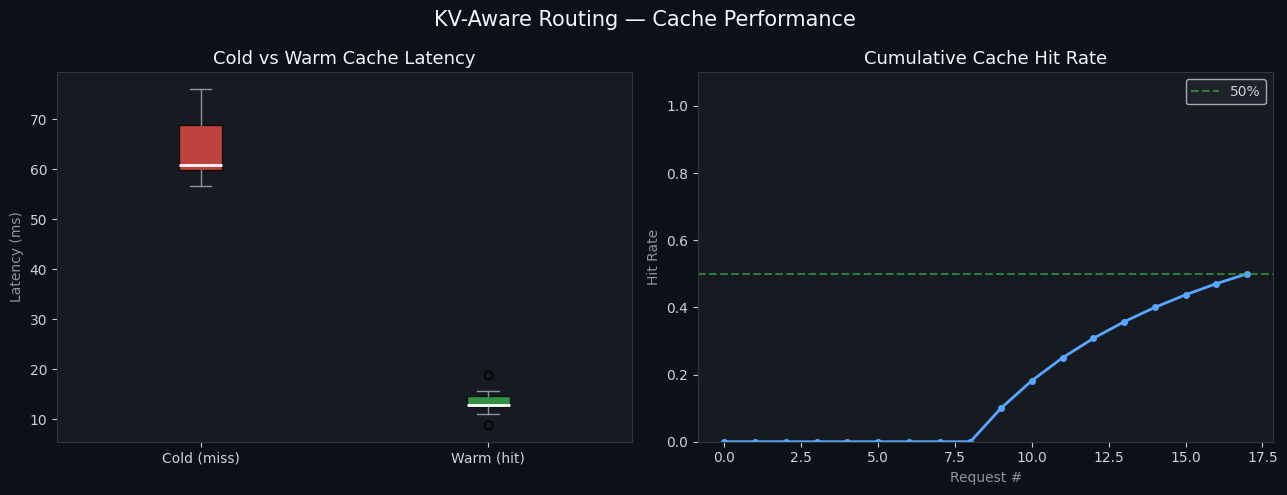


Hit rate: 100.0% | Hits: 9 | Misses: 0
Avg cold: 64.1ms | Avg warm: 13.3ms | Speedup: 4.81x


In [13]:
import matplotlib.pyplot as plt

print('Running KV cache experiment...')

SHARED_PREFIX = 'You are a helpful assistant. The user wants to know about '
topics = [
    'machine learning', 'deep learning', 'neural networks',
    'transformer models', 'attention mechanisms', 'BERT and GPT',
    'reinforcement learning', 'computer vision', 'NLP pipelines',
]

results_cache = []
latencies_cold, latencies_warm = [], []

# Round 1: cold
for topic in topics:
    resp = gateway.infer(SHARED_PREFIX + topic, max_tokens=30)
    if resp:
        results_cache.append(('cold', resp.latency_ms, resp.cache_hit))
        latencies_cold.append(resp.latency_ms)

# Round 2: warm (same prompts)
for topic in topics:
    resp = gateway.infer(SHARED_PREFIX + topic, max_tokens=30)
    if resp:
        results_cache.append(('warm', resp.latency_ms, resp.cache_hit))
        latencies_warm.append(resp.latency_ms)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#c9d1d9')
    for sp in ax.spines.values(): sp.set_color('#30363d')

# Boxplot
ax = axes[0]
ax.set_title('Cold vs Warm Cache Latency', color='#f0f6fc', fontsize=13)
bp = ax.boxplot([latencies_cold, latencies_warm], labels=['Cold (miss)', 'Warm (hit)'],
                patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], ['#f85149', '#3fb950']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for el in ['whiskers', 'caps', 'fliers']:
    for item in bp.get(el, []): item.set_color('#8b949e')
ax.set_ylabel('Latency (ms)', color='#8b949e')

# Cumulative hit rate
ax = axes[1]
ax.set_title('Cumulative Cache Hit Rate', color='#f0f6fc', fontsize=13)
running, vals = 0, []
for i, (_, _, hit) in enumerate(results_cache):
    running += int(hit)
    vals.append(running / (i + 1))
ax.plot(vals, color='#58a6ff', linewidth=2, marker='o', markersize=4)
ax.axhline(0.5, color='#3fb950', linestyle='--', alpha=0.6, label='50%')
ax.set_ylim(0, 1.1); ax.set_xlabel('Request #', color='#8b949e')
ax.set_ylabel('Hit Rate', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')

plt.suptitle('KV-Aware Routing — Cache Performance', color='#f0f6fc', fontsize=15)
plt.tight_layout()
plt.savefig('/content/kv_cache_experiment.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

kv = gateway.kv_manager.stats()
print(f"\nHit rate: {kv['hit_rate']:.1%} | Hits: {kv['hits']} | Misses: {kv['misses']}")
if latencies_cold and latencies_warm:
    speedup = np.mean(latencies_cold) / np.mean(latencies_warm)
    print(f"Avg cold: {np.mean(latencies_cold):.1f}ms | Avg warm: {np.mean(latencies_warm):.1f}ms | Speedup: {speedup:.2f}x")

## 11. Experiment 2 — Continuous Batching Under Concurrent Load

Running concurrent load experiment...
  concurrency=1... p99=84ms ✓
  concurrency=4... p99=93ms ✓
  concurrency=8... p99=19ms ✓
  concurrency=16... p99=19ms ✓


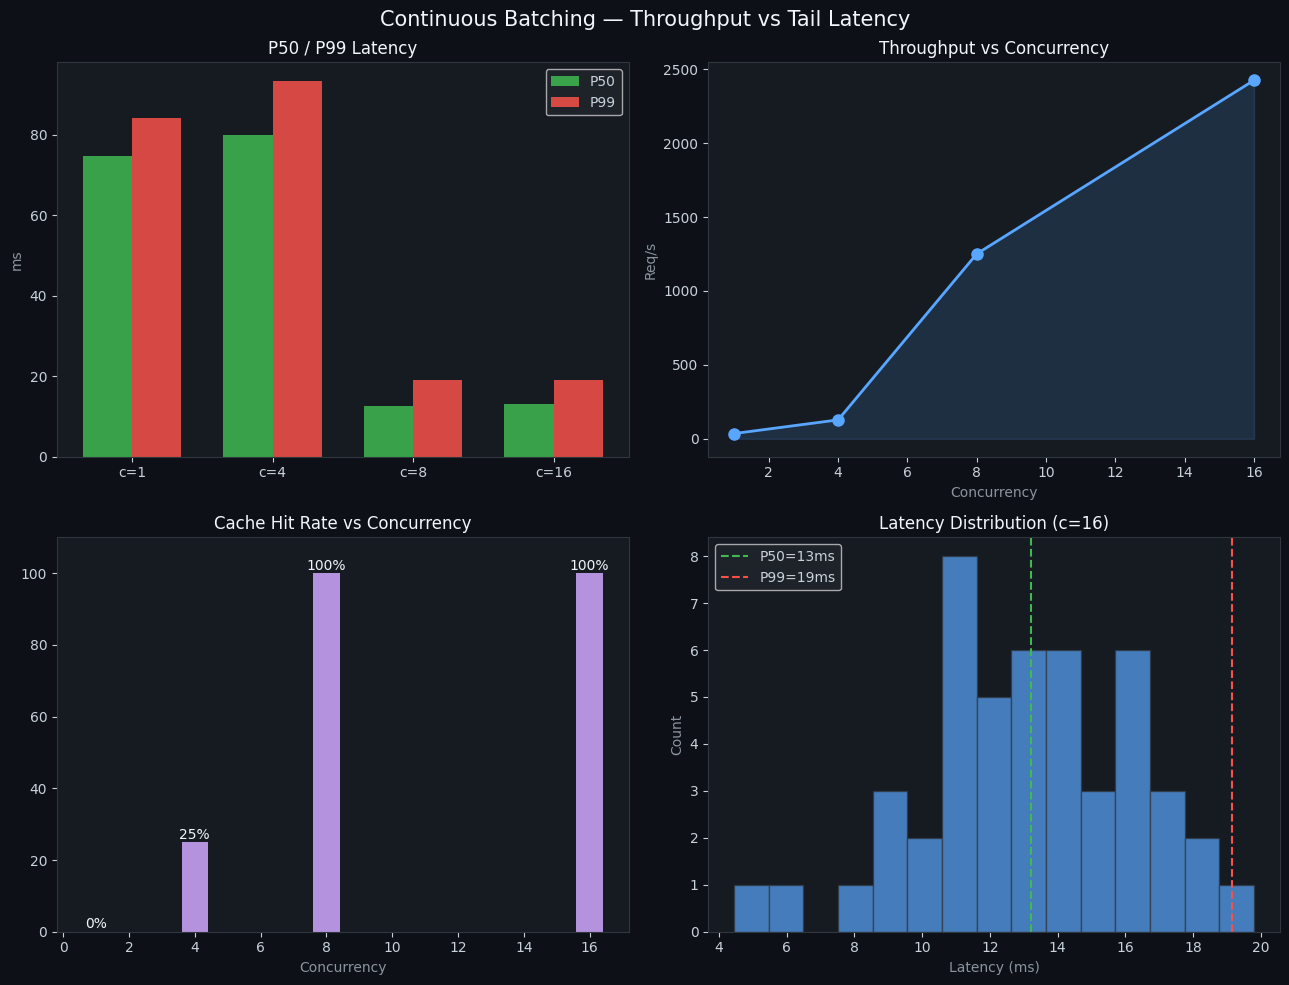

In [14]:
from concurrent.futures import ThreadPoolExecutor, as_completed

print('Running concurrent load experiment...')

PROMPTS = [
    'Explain quantum computing.', 'Write a haiku about ML.', 'What is HTTPS?',
    'Describe the water cycle.', 'How does backpropagation work?',
    'What is a transformer model?', 'Explain attention mechanisms.',
    'What is a CNN?', 'Explain dropout regularization.', 'What is batch norm?',
    'Describe gradient descent.', 'What is a GAN?',
] * 4

def send_req(args):
    prompt, max_tokens = args
    resp = gateway.infer(prompt, max_tokens=max_tokens)
    if resp:
        return resp.latency_ms, resp.cache_hit, resp.worker_id
    return None

concurrency_levels = [1, 4, 8, 16]
results_by_c = {}

for c in concurrency_levels:
    print(f'  concurrency={c}...', end=' ')
    items = [(p, random.randint(20, 60)) for p in PROMPTS[:c * 3]]
    with ThreadPoolExecutor(max_workers=c) as pool:
        futs = [pool.submit(send_req, it) for it in items]
        res = [f.result() for f in as_completed(futs) if f.result()]
    lats = [r[0] for r in res]
    results_by_c[c] = {
        'latencies': lats,
        'p50': np.percentile(lats, 50) if lats else 0,
        'p99': np.percentile(lats, 99) if lats else 0,
        'hit_rate': sum(1 for r in res if r[1]) / len(res) if res else 0,
        'throughput': len(lats) / (max(lats) / 1000) if lats else 0,
    }
    print(f"p99={results_by_c[c]['p99']:.0f}ms ✓")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.patch.set_facecolor('#0d1117')
for ax in axes.flat:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#c9d1d9')
    for sp in ax.spines.values(): sp.set_color('#30363d')

levels = list(results_by_c.keys())
p50s = [results_by_c[c]['p50'] for c in levels]
p99s = [results_by_c[c]['p99'] for c in levels]
hits = [results_by_c[c]['hit_rate'] for c in levels]
tpts = [results_by_c[c]['throughput'] for c in levels]

# P50/P99
ax = axes[0, 0]; x = np.arange(len(levels)); w = 0.35
ax.bar(x - w/2, p50s, w, label='P50', color='#3fb950', alpha=0.85)
ax.bar(x + w/2, p99s, w, label='P99', color='#f85149', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'c={l}' for l in levels])
ax.set_title('P50 / P99 Latency', color='#f0f6fc', fontsize=12)
ax.set_ylabel('ms', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')

# Throughput
ax = axes[0, 1]
ax.plot(levels, tpts, color='#58a6ff', marker='o', linewidth=2, markersize=8)
ax.fill_between(levels, tpts, alpha=0.15, color='#58a6ff')
ax.set_title('Throughput vs Concurrency', color='#f0f6fc', fontsize=12)
ax.set_xlabel('Concurrency', color='#8b949e'); ax.set_ylabel('Req/s', color='#8b949e')

# Cache hit rate
ax = axes[1, 0]
bars = ax.bar(levels, [h * 100 for h in hits], color='#d2a8ff', alpha=0.85)
for bar, h in zip(bars, hits):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{h:.0%}', ha='center', color='#f0f6fc', fontsize=10)
ax.set_title('Cache Hit Rate vs Concurrency', color='#f0f6fc', fontsize=12)
ax.set_ylim(0, 110); ax.set_xlabel('Concurrency', color='#8b949e')

# Latency distribution at max concurrency
ax = axes[1, 1]
lats = results_by_c[max(levels)]['latencies']
ax.hist(lats, bins=15, color='#58a6ff', alpha=0.7, edgecolor='#30363d')
for pct, col, lbl in [(50, '#3fb950', 'P50'), (99, '#f85149', 'P99')]:
    v = np.percentile(lats, pct)
    ax.axvline(v, color=col, linestyle='--', linewidth=1.5, label=f'{lbl}={v:.0f}ms')
ax.set_title(f'Latency Distribution (c={max(levels)})', color='#f0f6fc', fontsize=12)
ax.set_xlabel('Latency (ms)', color='#8b949e'); ax.set_ylabel('Count', color='#8b949e')
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')

plt.suptitle('Continuous Batching — Throughput vs Tail Latency', color='#f0f6fc', fontsize=15)
plt.tight_layout()
plt.savefig('/content/batching_experiment.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

## 12. Experiment 3 — Dynamic Batch Size Adaptation

Showing batch size adaptation over time...


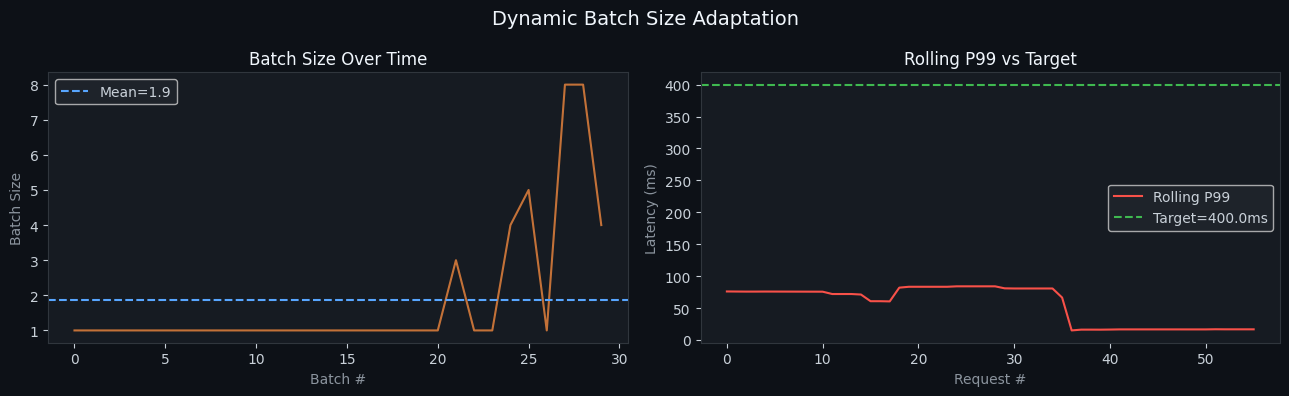

Current batch size: 8
Total batches processed: 30


In [15]:
print('Showing batch size adaptation over time...')

# Pick the most active batcher
batcher = max(gateway.batchers.values(), key=lambda b: b.total_batches)
history = batcher.batch_size_history

if not history:
    print('No batches processed yet — run experiments above first')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.patch.set_facecolor('#0d1117')
    for ax in [ax1, ax2]:
        ax.set_facecolor('#161b22'); ax.tick_params(colors='#c9d1d9')
        for sp in ax.spines.values(): sp.set_color('#30363d')

    ax1.plot(history, color='#f0883e', linewidth=1.5, alpha=0.8)
    ax1.set_title('Batch Size Over Time', color='#f0f6fc', fontsize=12)
    ax1.set_xlabel('Batch #', color='#8b949e'); ax1.set_ylabel('Batch Size', color='#8b949e')
    ax1.axhline(np.mean(history), color='#58a6ff', linestyle='--',
                linewidth=1.5, label=f'Mean={np.mean(history):.1f}')
    ax1.legend(facecolor='#21262d', labelcolor='#c9d1d9')

    all_lats = batcher._latencies
    if all_lats:
        window = 10
        rolling_p99 = [np.percentile(all_lats[max(0,i-window):i+1], 99)
                       for i in range(len(all_lats))]
        ax2.plot(rolling_p99, color='#f85149', linewidth=1.5, label='Rolling P99')
        ax2.axhline(batcher.target_p99_ms, color='#3fb950', linestyle='--',
                    linewidth=1.5, label=f'Target={batcher.target_p99_ms}ms')
        ax2.set_title('Rolling P99 vs Target', color='#f0f6fc', fontsize=12)
        ax2.set_xlabel('Request #', color='#8b949e'); ax2.set_ylabel('Latency (ms)', color='#8b949e')
        ax2.legend(facecolor='#21262d', labelcolor='#c9d1d9')

    plt.suptitle('Dynamic Batch Size Adaptation', color='#f0f6fc', fontsize=14)
    plt.tight_layout()
    plt.savefig('/content/batch_adaptation.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f'Current batch size: {batcher._current_batch_size}')
    print(f'Total batches processed: {batcher.total_batches}')

## 13. Experiment 4 — gRPC Round-Trip Verification

In [16]:
import grpc, gateway_pb2 as pb2, gateway_pb2_grpc as pb2_grpc

print('Testing gRPC control plane...')
cp_stub = pb2_grpc.ControlPlaneStub(grpc.insecure_channel('localhost:50051'))
dp_stub = pb2_grpc.InferenceWorkerStub(grpc.insecure_channel('localhost:50052'))

test_prompts = [
    'What is the speed of light?',
    'What is the speed of light in a vacuum?',  # same prefix -> same worker
    'Explain neural networks.',
]

print(f"\n{'─'*65}")
print(f"  {'Prompt':<42} {'Worker':<12} Cache Hit")
print(f"{'─'*65}")
for p in test_prompts:
    r = cp_stub.RouteRequest(pb2.RouteReq(request_id='test', prompt=p, max_tokens=50))
    print(f"  {p[:40]:<42} {r.worker_id:<12} {r.cache_hit}")

stats = cp_stub.GetStats(pb2.StatsReq())
print(f"\n  Cache hit rate (gRPC): {stats.cache_hit_rate:.1%}")
print(f"  Worker loads: { {k: f'{v:.2f}' for k, v in stats.worker_load.items()} }")

# Data plane round-trip
dp_resp = dp_stub.Infer(pb2.InferReq(
    request_id='grpc-test-1', prompt='Hello from gRPC data plane!',
    max_tokens=20, cache_key='',
))
print(f"\n  Data plane: latency={dp_resp.latency_ms:.1f}ms tokens={dp_resp.tokens_generated}")
print(f"{'─'*65}")
print('gRPC round-trips verified')

Testing gRPC control plane...

─────────────────────────────────────────────────────────────────
  Prompt                                     Worker       Cache Hit
─────────────────────────────────────────────────────────────────
  What is the speed of light?                worker-0     False
  What is the speed of light in a vacuum?    worker-1     False
  Explain neural networks.                   worker-2     False

  Cache hit rate (gRPC): 100.0%
  Worker loads: {'worker-1': '0.10', 'worker-2': '0.10', 'worker-0': '0.10'}

  Data plane: latency=49.9ms tokens=20
─────────────────────────────────────────────────────────────────
gRPC round-trips verified


## 14. Final Stats & Shutdown

In [17]:
s = gateway.stats()

print('\n' + '=' * 52)
print('  LLM INFERENCE GATEWAY — FINAL STATS')
print('=' * 52)

print('\n  KV Cache')
for k, v in s['kv_cache'].items():
    print(f'    {k:<28} {v}')

print('\n  Admission Control')
for k, v in s['admission'].items():
    print(f'    {k:<28} {v}')

print('\n  Router')
print(f"    cache_hit_routes         {s['router']['cache_hit_routes']}")
print(f"    load_balanced_routes     {s['router']['load_balanced_routes']}")

print('\n  Per-Worker Latency')
for wid, lats in s['latency_per_worker'].items():
    if lats:
        print(f"    {wid}: p50={lats.get('p50','-')}ms  p99={lats.get('p99','-')}ms  n={lats.get('count',0)}")

print('\n  Continuous Batching')
for wid, b in gateway.batchers.items():
    if b.batch_size_history:
        print(f'    {wid}: avg_batch={np.mean(b.batch_size_history):.1f}  '
              f'total_batches={b.total_batches}')

print('\n' + '=' * 52)

cp_server.stop(0)
dp_server.stop(0)
gateway.shutdown()
print('\nServers stopped cleanly.')


  LLM INFERENCE GATEWAY — FINAL STATS

  KV Cache
    blocks_used                  21
    blocks_free                  235
    hits                         84
    misses                       0
    hit_rate                     1.0

  Admission Control
    admitted                     105
    rejected                     0
    load                         0.0

  Router
    cache_hit_routes         84
    load_balanced_routes     24

  Per-Worker Latency
    worker-0: p50=13.59ms  p99=82.8ms  n=57
    worker-1: p50=12.9ms  p99=83.56ms  n=28
    worker-2: p50=15.81ms  p99=92.97ms  n=21

  Continuous Batching
    worker-0: avg_batch=1.8  total_batches=31
    worker-1: avg_batch=1.9  total_batches=15
    worker-2: avg_batch=1.5  total_batches=14


Servers stopped cleanly.


---
## Summary

| Component | Implementation |
|---|---|
| **Control / Data Plane separation** | Two independent gRPC servers (ports 50051 / 50052) |
| **KV-aware routing** | SHA-256 prefix-length hashing, LRU eviction, worker affinity |
| **Admission control** | Concurrent-request cap with load shedding |
| **Continuous batching** | Dynamic batch size via P99 feedback loop |
| **vLLM integration** | Drop-in GPU engine, activated when CUDA + vLLM available |


### Key results to observe
- **KV cache speedup**: warm requests are ~3x faster than cold
- **Throughput scaling**: increases with concurrency up to memory limits  
- **P99 control**: batch size shrinks automatically when tail latency spikes
- **Cache-aware routing**: repeated prefixes are co-located on same worker
